In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pillow_lab_rotation.simulate import make_ctds_params, simulate_ctds_data
from pillow_lab_rotation.ctds import CTDS

In [9]:
A = np.random.randn(10, 10)
B = np.random.randn(10, 2)
np.block([A, B]).shape

(10, 12)

In [ ]:
# Ground truth parameters
De, Di = 2, 2
Ne, Ni = 8, 4
n_trials, T = 50, 100

true_params = make_ctds_params(De, Di, Ne, Ni, seed=6)
Y, X_true = simulate_ctds_data(**true_params, n_trials=n_trials, T=T)
print(f"Y shape: {Y.shape}, X_true shape: {X_true.shape}")

Y shape: (50, 100, 12, 1), X_true shape: (50, 100, 4, 1)


In [ ]:
# Fit CTDS
model = CTDS(De=De, Di=Di, Ne=Ne, Ni=Ni)
model.fit(Y)
print(f"Final LL: {model.log_likelihood():.4f}")

Final LL: -13.7903


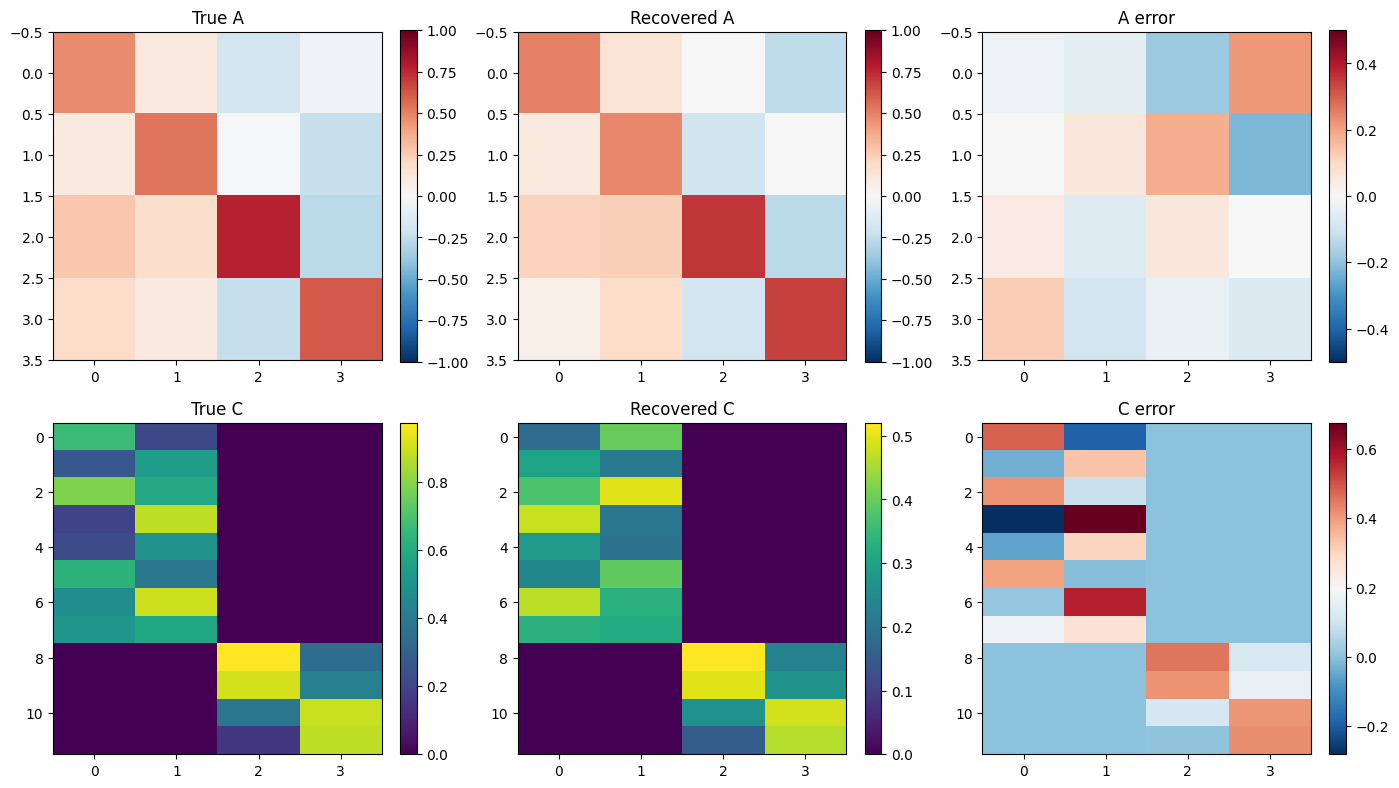

A RMSE: 0.1153
C RMSE: 0.2294


In [ ]:
# Compare recovered vs true parameters
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].imshow(true_params['A'], cmap='RdBu_r', vmin=-1, vmax=1)
axes[0, 0].set_title('True A')
axes[0, 1].imshow(model.A, cmap='RdBu_r', vmin=-1, vmax=1)
axes[0, 1].set_title('Recovered A')
axes[0, 2].imshow(true_params['A'] - model.A, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
axes[0, 2].set_title('A error')

axes[1, 0].imshow(true_params['C'], aspect='auto', vmin=0)
axes[1, 0].set_title('True C')
axes[1, 1].imshow(model.C, aspect='auto', vmin=0)
axes[1, 1].set_title('Recovered C')
axes[1, 2].imshow(true_params['C'] - model.C, aspect='auto', cmap='RdBu_r')
axes[1, 2].set_title('C error')

for ax in axes.flat:
    ax.colorbar = plt.colorbar(ax.images[0], ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

print(f"A RMSE: {np.sqrt(np.mean((true_params['A'] - model.A)**2)):.4f}")
print(f"C RMSE: {np.sqrt(np.mean((true_params['C'] - model.C)**2)):.4f}")

In [ ]:
# Check Dale's law constraints on recovered A
A_no_diag = model.A.copy()
np.fill_diagonal(A_no_diag, 0)

print("Dale's law check on recovered A (off-diagonal):")
print(f"  E columns min (should be >= 0): {A_no_diag[:, :De].min():.6f}")
print(f"  I columns max (should be <= 0): {A_no_diag[:, De:].max():.6f}")

print(f"\nBlock diagonal check on recovered C:")
print(f"  E-to-I block max abs (should be 0): {np.abs(model.C[Ne:, :De]).max():.6f}")
print(f"  I-to-E block max abs (should be 0): {np.abs(model.C[:Ne, De:]).max():.6f}")
print(f"  E-to-E block min (should be >= 0): {model.C[:Ne, :De].min():.6f}")
print(f"  I-to-I block min (should be >= 0): {model.C[Ne:, De:].min():.6f}")

Dale's law check on recovered A (off-diagonal):
  E columns min (should be >= 0): 0.000000
  I columns max (should be <= 0): 0.000000

Block diagonal check on recovered C:
  E-to-I block max abs (should be 0): 0.000000
  I-to-E block max abs (should be 0): 0.000000
  E-to-E block min (should be >= 0): 0.185137
  I-to-I block min (should be >= 0): 0.153931


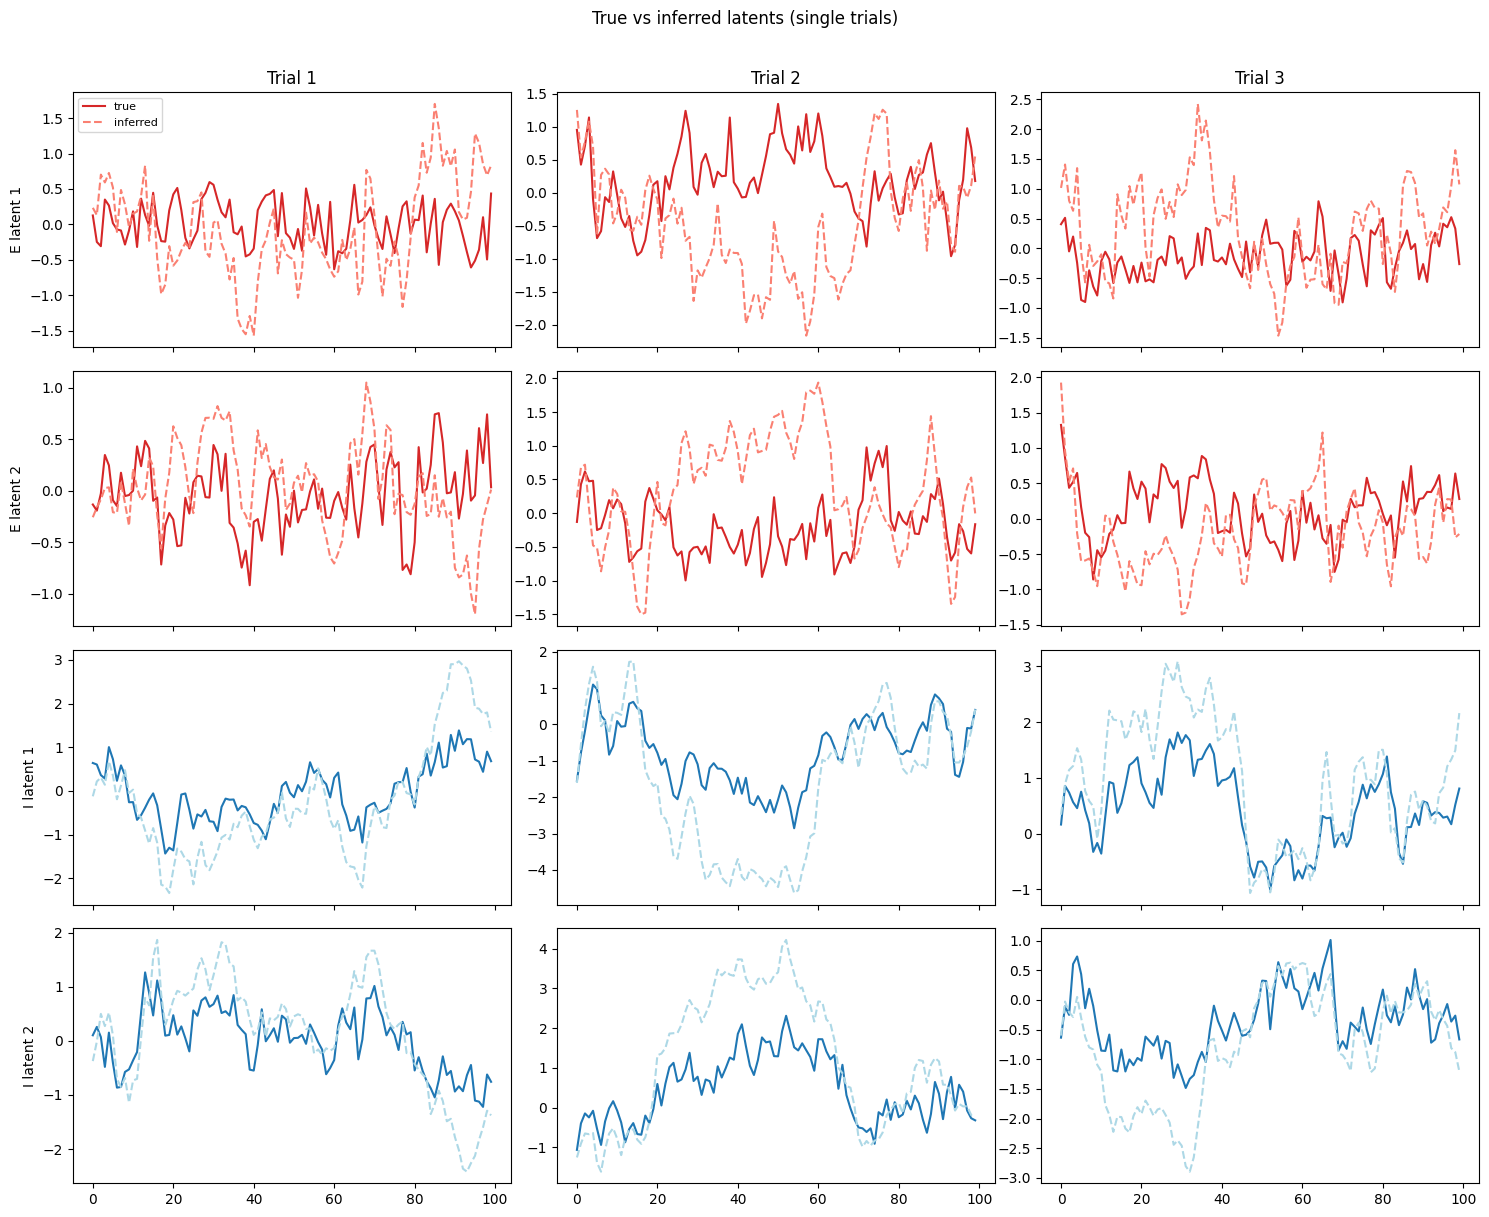

In [ ]:
# Compare inferred vs true latents for a few example trials
# Note: latents are identifiable only up to positive diagonal scaling (see notes sec 3.2),
# so we compare correlations rather than raw values.

inferred = model.m[..., 0]  # (n_trials, T, D)
true_lat = X_true[..., 0]   # (n_trials, T, D)

n_show = 3
D = De + Di
fig, axes = plt.subplots(D, n_show, figsize=(5 * n_show, 3 * D), sharex=True)

labels = [f'E latent {i+1}' for i in range(De)] + [f'I latent {i+1}' for i in range(Di)]
colors_true = ['tab:red'] * De + ['tab:blue'] * Di
colors_inf = ['salmon'] * De + ['lightblue'] * Di

for trial in range(n_show):
    for d in range(D):
        ax = axes[d, trial]
        ax.plot(true_lat[trial, :, d], color=colors_true[d], label='true')
        ax.plot(inferred[trial, :, d], color=colors_inf[d], ls='--', label='inferred')
        if trial == 0:
            ax.set_ylabel(labels[d])
        if d == 0:
            ax.set_title(f'Trial {trial + 1}')
        if d == 0 and trial == 0:
            ax.legend(fontsize=8)

plt.suptitle('True vs inferred latents (single trials)', y=1.01)
plt.tight_layout()
plt.show()

Per-latent Pearson correlation (true vs inferred):
  E latent 1: r = 0.7354
  E latent 2: r = 0.7972
  I latent 1: r = 0.9343
  I latent 2: r = 0.9007


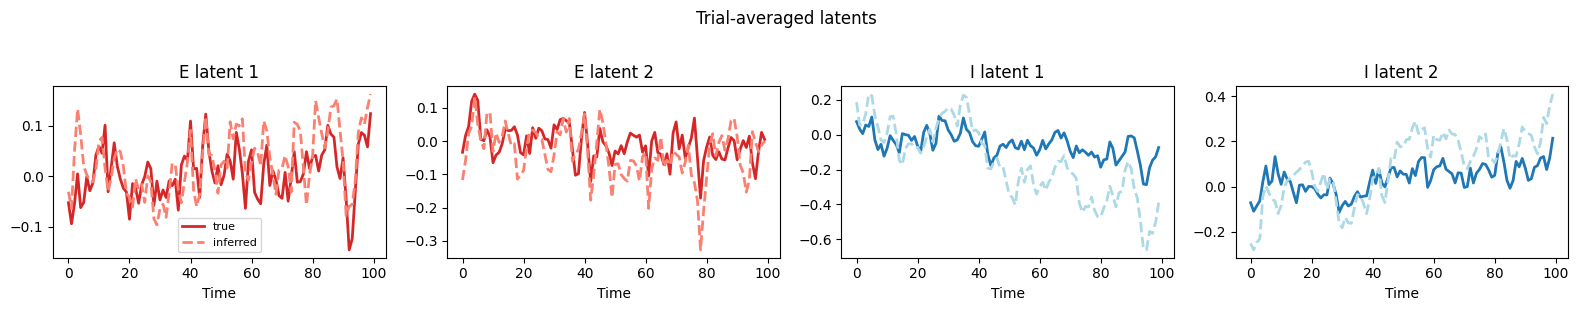

In [ ]:
# Per-latent correlation between true and inferred (across all trials and time)
true_flat = true_lat.reshape(-1, D)
inf_flat = inferred.reshape(-1, D)

print("Per-latent Pearson correlation (true vs inferred):")
for d in range(D):
    r = np.corrcoef(true_flat[:, d], inf_flat[:, d])[0, 1]
    print(f"  {labels[d]}: r = {r:.4f}")

# Trial-averaged latents
fig, axes = plt.subplots(1, D, figsize=(4 * D, 3), sharey=False)
for d in range(D):
    ax = axes[d]
    ax.plot(true_lat.mean(0)[:, d], color=colors_true[d], lw=2, label='true')
    ax.plot(inferred.mean(0)[:, d], color=colors_inf[d], lw=2, ls='--', label='inferred')
    ax.set_title(labels[d])
    ax.set_xlabel('Time')
    if d == 0:
        ax.legend(fontsize=8)

plt.suptitle('Trial-averaged latents', y=1.02)
plt.tight_layout()
plt.show()

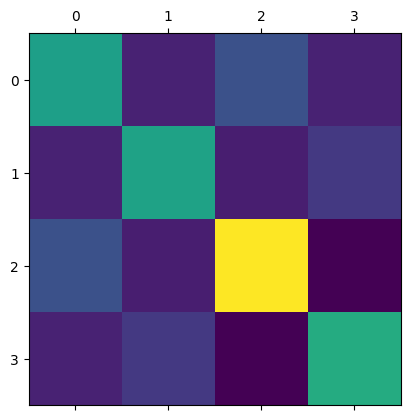

In [ ]:
plt.matshow(model.Q)